<a href="https://colab.research.google.com/github/Dokkae-bi/Email_CLI/blob/main/Homework5/Homework_5_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework 5: Vision Transformers for Image Classification

ECGR 4106 — CIFAR-100. Methodology per TA feedback: class-balanced 45k/5k train/val split, best-validation checkpointing, checkpoint restored before a single test evaluation.

## Problem 1: Vision Transformer from Scratch vs. ResNet-18

Cell 1 - Setup

In [1]:
# ECGR 4106 - Homework 5
# Vision Transformers on CIFAR-100

import os
import time
import math
import copy
import json
import numpy as np
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader, Subset
from torch.utils.flop_counter import FlopCounterMode

# Device selection with CPU fallback (required by assignment)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# Reproducibility (note: full determinism not guaranteed on GPU,
# metrics may drift slightly between runs)
print(f"PyTorch: {torch.__version__} | Torchvision: {torchvision.__version__}")

SEED = 42
torch.manual_seed(SEED)
if device.type == "cuda":
    torch.cuda.manual_seed_all(SEED)


Using device: cuda
GPU: Tesla T4
PyTorch: 2.11.0+cu128 | Torchvision: 0.26.0+cu128


Cell 2 - Data pipeline and train/val split

In [2]:
# CIFAR-100: 100 classes, 32x32 RGB. Official split: 50k train / 10k test.
# Methodology (per TA feedback): the 50k training set is divided into a
# class-balanced 45k train / 5k validation split (450/50 images per class,
# fixed seed). Model selection (best-epoch checkpointing) uses VALIDATION
# accuracy only; the test set is evaluated exactly once per model, after
# restoring the best-validation checkpoint.

DRIVE_DIR = "/content/drive/MyDrive/ECGR4106/data"
CACHE = f"{DRIVE_DIR}/cifar-100-python.tar.gz"
LOCAL_ARCHIVE = "./data/cifar-100-python.tar.gz"

# Mount Drive
try:
    from google.colab import drive
    drive.mount('/content/drive')
    drive_ok = True
except Exception as e:
    print(f"Drive unavailable ({e}); proceeding without cache")
    drive_ok = False

# Restore from cache if we don't have the data locally
if drive_ok and not os.path.exists("./data/cifar-100-python") and os.path.exists(CACHE):
    os.makedirs("./data", exist_ok=True)
    !cp {CACHE} ./data/
    print("Restored CIFAR-100 archive from Drive cache")

# --- Class-balanced train/val split indices
base_train = torchvision.datasets.CIFAR100(root="./data", train=True, download=True)
targets = np.array(base_train.targets)

split_gen = torch.Generator().manual_seed(SEED)
TRAIN_IDX, VAL_IDX = [], []
for class_id in range(100):
    class_indices = np.where(targets == class_id)[0]
    perm = torch.randperm(len(class_indices), generator=split_gen).numpy()
    shuffled = class_indices[perm]
    TRAIN_IDX.extend(shuffled[:450])
    VAL_IDX.extend(shuffled[450:])
TRAIN_IDX, VAL_IDX = np.array(TRAIN_IDX), np.array(VAL_IDX)
assert len(TRAIN_IDX) == 45000 and len(VAL_IDX) == 5000
assert len(np.intersect1d(TRAIN_IDX, VAL_IDX)) == 0

if drive_ok and os.path.exists(LOCAL_ARCHIVE) and not os.path.exists(CACHE):
    os.makedirs(DRIVE_DIR, exist_ok=True)
    !cp {LOCAL_ARCHIVE} {CACHE}
    print("Saved CIFAR-100 archive to Drive cache")

RESULT_DIR = "/content/drive/MyDrive/ECGR4106" if drive_ok else "./results"
os.makedirs(RESULT_DIR, exist_ok=True)
print(f"Results will be saved to: {RESULT_DIR}")

# --- Problem 1 pipeline: 32x32, CIFAR-100 channel stats, no augmentation
CIFAR100_MEAN = (0.5071, 0.4865, 0.4409)
CIFAR100_STD  = (0.2673, 0.2564, 0.2762)

p1_transform = T.Compose([
    T.ToTensor(),
    T.Normalize(CIFAR100_MEAN, CIFAR100_STD),
])

p1_full  = torchvision.datasets.CIFAR100(root="./data", train=True,  download=False, transform=p1_transform)
p1_test_set = torchvision.datasets.CIFAR100(root="./data", train=False, download=True, transform=p1_transform)
p1_train_set = Subset(p1_full, TRAIN_IDX)
p1_val_set   = Subset(p1_full, VAL_IDX)

BATCH_SIZE = 64  # Problem 1 spec

train_loader = DataLoader(p1_train_set, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=(device.type == "cuda"))
val_loader   = DataLoader(p1_val_set,   batch_size=256, shuffle=False,
                          num_workers=2, pin_memory=(device.type == "cuda"))
test_loader  = DataLoader(p1_test_set,  batch_size=256, shuffle=False,
                          num_workers=2, pin_memory=(device.type == "cuda"))

print(f"Train: {len(p1_train_set)}  Val: {len(p1_val_set)}  Test: {len(p1_test_set)}")


Drive unavailable (mount failed); proceeding without cache


100%|██████████| 169M/169M [57:02<00:00, 49.4kB/s]


Results will be saved to: ./results
Train: 45000  Val: 5000  Test: 10000


Cell 3 - ViT from scratch

In [3]:
class PatchEmbed(nn.Module):
    """Splits image into non-overlapping patches and linearly projects each
    to the embedding dimension. Implemented as a Conv2d with kernel = stride
    = patch size, which is mathematically identical to unfold + linear."""
    def __init__(self, img_size=32, patch_size=4, in_chans=3, embed_dim=256):
        super().__init__()
        assert img_size % patch_size == 0, "image size must be divisible by patch size"
        self.num_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)
        x = x.flatten(2).transpose(1, 2)
        return x


class MultiHeadSelfAttention(nn.Module):
    """Standard scaled dot-product multi-head self-attention,
    written out explicitly rather than using nn.MultiheadAttention."""
    def __init__(self, embed_dim, num_heads):
        super().__init__()
        assert embed_dim % num_heads == 0, "embed_dim must be divisible by num_heads"
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.scale = self.head_dim ** -0.5

        self.qkv = nn.Linear(embed_dim, embed_dim * 3)
        self.proj = nn.Linear(embed_dim, embed_dim)

    def forward(self, x):
        B, N, D = x.shape
        qkv = self.qkv(x)
        qkv = qkv.reshape(B, N, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]

        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        out = attn @ v
        out = out.transpose(1, 2).reshape(B, N, D)
        return self.proj(out)


class TransformerBlock(nn.Module):
    """Pre-LayerNorm encoder block (same norm_first convention as HW4):
    x = x + MSA(LN(x));  x = x + MLP(LN(x))"""
    def __init__(self, embed_dim, num_heads, mlp_ratio=4.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = MultiHeadSelfAttention(embed_dim, num_heads)
        self.norm2 = nn.LayerNorm(embed_dim)
        hidden = int(embed_dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, embed_dim),
            nn.Dropout(dropout),
        )
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        x = x + self.drop(self.attn(self.norm1(x)))
        x = x + self.mlp(self.norm2(x))
        return x


class ViT(nn.Module):
    """Vision Transformer for CIFAR-100.
    patch embed -> [CLS] + learned positional embeddings -> L encoder blocks
    -> LayerNorm -> linear head on the CLS token."""
    def __init__(self, img_size=32, patch_size=4, in_chans=3, num_classes=100,
                 embed_dim=256, depth=4, num_heads=4, mlp_ratio=4.0, dropout=0.1):
        super().__init__()
        self.patch_embed = PatchEmbed(img_size, patch_size, in_chans, embed_dim)
        num_patches = self.patch_embed.num_patches

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))
        self.pos_drop = nn.Dropout(dropout)

        self.blocks = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, mlp_ratio, dropout)
            for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

        # Initialization
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.trunc_normal_(m.weight, std=0.02)
            if m.bias is not None:
                nn.init.zeros_(m.bias)

    def forward(self, x):
        B = x.shape[0]
        x = self.patch_embed(x)
        cls = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1)
        x = self.pos_drop(x + self.pos_embed)
        for blk in self.blocks:
            x = blk(x)
        x = self.norm(x)
        return self.head(x[:, 0])

Cell 4 - Sanity check

In [4]:
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Quick forward-pass check before committing to training
_test_model = ViT(patch_size=4, embed_dim=256, depth=4, num_heads=4).to(device)
_dummy = torch.randn(2, 3, 32, 32, device=device)
_out = _test_model(_dummy)
print(f"Output shape: {_out.shape}")
print(f"Params: {count_params(_test_model):,}")
del _test_model, _dummy, _out


Output shape: torch.Size([2, 100])
Params: 3,214,692


Cell 5 - Training/eval harness + FLOPs measurement

In [5]:
# Cell 5 -- Training/eval harness + FLOPs measurement (Problem 1)
# Per TA feedback: per-epoch validation, best-val checkpointing, restore
# best checkpoint, then a SINGLE test evaluation.

criterion = nn.CrossEntropyLoss()

def measure_flops(model, batch_size=1):
    """Forward-pass FLOPs for a single image using torch.utils.flop_counter
    (counts matmul/conv MACs as 2 FLOPs; elementwise ops, softmax, and
    normalization excluded -- consistent with prior homework conventions)."""
    model.eval()
    x = torch.randn(batch_size, 3, 32, 32, device=device)
    flop_counter = FlopCounterMode(display=False)
    with flop_counter:
        with torch.no_grad():
            model(x)
    return flop_counter.get_total_flops()

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        preds = model(images).argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return 100.0 * correct / total

def train_model(model, name, num_epochs=10, lr=0.001):
    """Trains with assignment hyperparameters. Timing covers the training
    loop only (CUDA-synchronized); validation runs outside the timed window.
    Checkpoints on best validation accuracy, restores that checkpoint, and
    evaluates the test set once. Returns (history, best_val, best_epoch,
    test_acc); history rows are (epoch, train_loss, val_acc, epoch_time_s)."""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = []
    best_val, best_epoch, best_state = float("-inf"), 0, None

    for epoch in range(1, num_epochs + 1):
        model.train()
        if device.type == "cuda":
            torch.cuda.synchronize()
        t0 = time.time()

        running_loss, n_batches = 0.0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            n_batches += 1

        if device.type == "cuda":
            torch.cuda.synchronize()
        epoch_time = time.time() - t0                # training only

        val_acc = evaluate(model, val_loader)        # outside timed window
        train_loss = running_loss / n_batches
        history.append((epoch, train_loss, val_acc, epoch_time))

        if val_acc > best_val:
            best_val, best_epoch = val_acc, epoch
            best_state = {k: v.detach().cpu().clone()
                          for k, v in model.state_dict().items()}

        print(f"[{name}] epoch {epoch:2d}/{num_epochs} | "
              f"train loss {train_loss:.4f} | val acc {val_acc:.2f}% | "
              f"{epoch_time:.1f}s")

    model.load_state_dict(best_state)               # restore best-val checkpoint
    test_acc = evaluate(model, test_loader)          # single test evaluation
    print(f"[{name}] best val {best_val:.2f}% @ epoch {best_epoch} | "
          f"test acc (restored ckpt): {test_acc:.2f}%")
    return history, best_val, best_epoch, test_acc


Cell 6 - ViT configuration sweep

In [6]:
# Cell 6 -- ViT configuration sweep

CONFIGS = [
    ("C1-base",   4, 256, 4, 4),
    ("C2-patch8", 8, 256, 4, 4),
    ("C3-embed512", 4, 512, 4, 4),
    ("C4-depth8", 4, 256, 8, 4),
    ("C5-heads8", 4, 256, 4, 8),
]

results = {}

for name, patch, embed, depth, heads in CONFIGS:
    print(f"\n{'='*60}\n{name}: patch={patch}, embed={embed}, "
          f"depth={depth}, heads={heads}\n{'='*60}")

    torch.manual_seed(SEED)
    model = ViT(img_size=32, patch_size=patch, num_classes=100,
                embed_dim=embed, depth=depth, num_heads=heads,
                mlp_ratio=4.0).to(device)

    n_params = count_params(model)
    flops = measure_flops(model)
    print(f"Params: {n_params:,} | FLOPs/image (fwd): {flops/1e6:.1f} MFLOPs")

    history, best_val, best_epoch, test_acc = train_model(
        model, name, num_epochs=10, lr=0.001)

    results[name] = {
        "config": (patch, embed, depth, heads),
        "params": n_params,
        "flops": flops,
        "history": history,
        "best_val_acc": best_val,
        "best_epoch": best_epoch,
        "test_acc": test_acc,
        "mean_epoch_time": sum(h[3] for h in history) / len(history),
    }

    del model
    if device.type == "cuda":
        torch.cuda.empty_cache()



C1-base: patch=4, embed=256, depth=4, heads=4
Params: 3,214,692 | FLOPs/image (fwd): 427.9 MFLOPs
[C1-base] epoch  1/10 | train loss 3.9627 | val acc 12.24% | 26.3s
[C1-base] epoch  2/10 | train loss 3.5280 | val acc 16.52% | 27.0s
[C1-base] epoch  3/10 | train loss 3.3888 | val acc 15.08% | 27.9s
[C1-base] epoch  4/10 | train loss 3.3126 | val acc 19.02% | 29.8s
[C1-base] epoch  5/10 | train loss 3.1892 | val acc 21.10% | 29.0s
[C1-base] epoch  6/10 | train loss 3.1160 | val acc 21.30% | 28.8s
[C1-base] epoch  7/10 | train loss 3.0485 | val acc 22.72% | 29.5s
[C1-base] epoch  8/10 | train loss 2.9760 | val acc 25.22% | 28.9s
[C1-base] epoch  9/10 | train loss 2.9254 | val acc 24.78% | 29.0s
[C1-base] epoch 10/10 | train loss 2.9068 | val acc 25.60% | 29.1s
[C1-base] best val 25.60% @ epoch 10 | test acc (restored ckpt): 26.23%

C2-patch8: patch=8, embed=256, depth=4, heads=4
Params: 3,239,268 | FLOPs/image (fwd): 109.8 MFLOPs
[C2-patch8] epoch  1/10 | train loss 4.0728 | val acc 8.18

Cell 7 - ResNet-18 baseline

In [7]:
# Cell 7 -- ResNet-18 baseline (pretrained, per assignment's allowance)

from torchvision.models import resnet18, ResNet18_Weights

torch.manual_seed(SEED)
resnet = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
resnet.fc = nn.Linear(resnet.fc.in_features, 100)
resnet = resnet.to(device)

n_params_rn = count_params(resnet)
flops_rn = measure_flops(resnet)
print(f"ResNet-18 | Params: {n_params_rn:,} | "
      f"FLOPs/image (fwd): {flops_rn/1e6:.1f} MFLOPs")

history_rn, best_val_rn, best_ep_rn, test_rn = train_model(
    resnet, "ResNet-18", num_epochs=10, lr=0.001)

results["ResNet-18"] = {
    "config": "pretrained, ImageNet init",
    "params": n_params_rn,
    "flops": flops_rn,
    "history": history_rn,
    "best_val_acc": best_val_rn,
    "best_epoch": best_ep_rn,
    "test_acc": test_rn,
    "mean_epoch_time": sum(h[3] for h in history_rn) / len(history_rn),
}


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 182MB/s]


ResNet-18 | Params: 11,227,812 | FLOPs/image (fwd): 74.1 MFLOPs
[ResNet-18] epoch  1/10 | train loss 2.9135 | val acc 31.46% | 23.9s
[ResNet-18] epoch  2/10 | train loss 2.1660 | val acc 40.14% | 23.5s
[ResNet-18] epoch  3/10 | train loss 1.8234 | val acc 44.38% | 23.6s
[ResNet-18] epoch  4/10 | train loss 1.5849 | val acc 46.46% | 23.8s
[ResNet-18] epoch  5/10 | train loss 1.3862 | val acc 48.38% | 23.8s
[ResNet-18] epoch  6/10 | train loss 1.1455 | val acc 47.66% | 23.7s
[ResNet-18] epoch  7/10 | train loss 0.9636 | val acc 48.80% | 23.3s
[ResNet-18] epoch  8/10 | train loss 0.8190 | val acc 48.12% | 23.0s
[ResNet-18] epoch  9/10 | train loss 0.6690 | val acc 47.44% | 23.1s
[ResNet-18] epoch 10/10 | train loss 0.5779 | val acc 49.20% | 23.6s
[ResNet-18] best val 49.20% @ epoch 10 | test acc (restored ckpt): 49.83%


Cell 8 - Problem 1 summary table

In [8]:
# Cell 8 -- Problem 1 summary table

import pandas as pd

rows = []
for name, r in results.items():
    if isinstance(r["config"], tuple):
        patch, embed, depth, heads = r["config"]
        cfg_str = f"P{patch}/D{embed}/L{depth}/H{heads}"
    else:
        cfg_str = r["config"]
    rows.append({
        "Model": name,
        "Config": cfg_str,
        "Params (M)": r["params"] / 1e6,
        "FLOPs/image (M)": r["flops"] / 1e6,
        "Mean train time/epoch (s)": r["mean_epoch_time"],
        "Best val acc (%)": r["best_val_acc"],
        "Best epoch": r["best_epoch"],
        "Test acc (%)": r["test_acc"],
    })

df = pd.DataFrame(rows)
df = df.round({"Params (M)": 2, "FLOPs/image (M)": 1,
               "Mean train time/epoch (s)": 1,
               "Best val acc (%)": 2, "Test acc (%)": 2})
print(df.to_string(index=False))
print()
print(df.to_markdown(index=False))


      Model                    Config  Params (M)  FLOPs/image (M)  Mean train time/epoch (s)  Best val acc (%)  Best epoch  Test acc (%)
    C1-base             P4/D256/L4/H4        3.21            427.9                       28.5             25.60          10         26.23
  C2-patch8             P8/D256/L4/H4        3.24            109.8                       19.5             14.38           7         14.49
C3-embed512             P4/D512/L4/H4       12.72           1673.6                       85.8              9.98           8         10.29
  C4-depth8             P4/D256/L8/H4        6.37            854.1                       57.1             21.60          10         21.86
  C5-heads8             P4/D256/L4/H8        3.21            427.9                       30.5             30.36          10         30.01
  ResNet-18 pretrained, ImageNet init       11.23             74.1                       23.5             49.20          10         49.83

| Model       | Config           

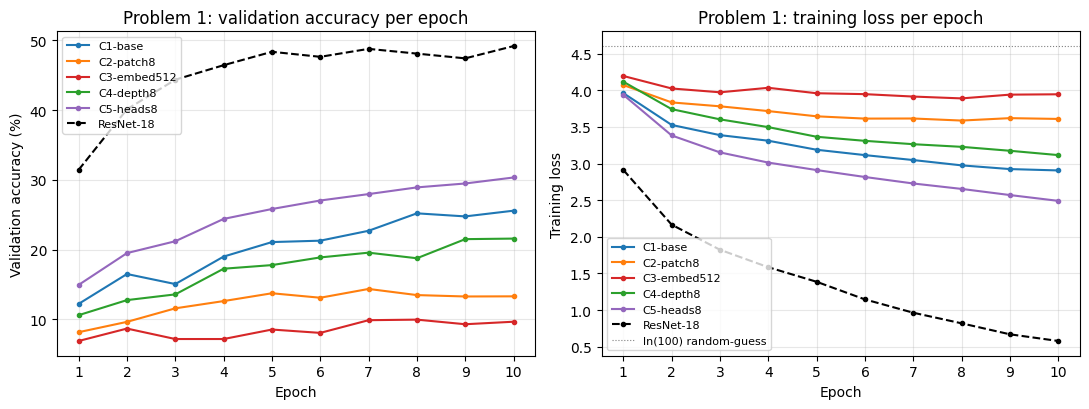

In [9]:
# Figure 1 -- Problem 1 convergence (validation accuracy + training loss).
# History rows are (epoch, train_loss, val_acc, epoch_time). Saved to RESULT_DIR.
import matplotlib.pyplot as plt

def _series(hist, col):
    return [h[0] for h in hist], [h[col] for h in hist]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))
styles = {"C1-base": ("tab:blue", "-"), "C2-patch8": ("tab:orange", "-"),
          "C3-embed512": ("tab:red", "-"), "C4-depth8": ("tab:green", "-"),
          "C5-heads8": ("tab:purple", "-"), "ResNet-18": ("black", "--")}
for name, (c, ls) in styles.items():
    ep, acc = _series(results[name]["history"], 2)
    ax1.plot(ep, acc, ls, color=c, marker="o", ms=3, label=name)
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Validation accuracy (%)")
ax1.set_title("Problem 1: validation accuracy per epoch")
ax1.legend(fontsize=8); ax1.grid(alpha=0.3); ax1.set_xticks(range(1, 11))

for name, (c, ls) in styles.items():
    ep, loss = _series(results[name]["history"], 1)
    ax2.plot(ep, loss, ls, color=c, marker="o", ms=3, label=name)
ax2.axhline(4.605, color="gray", lw=0.8, ls=":", label="ln(100) random-guess")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Training loss")
ax2.set_title("Problem 1: training loss per epoch")
ax2.legend(fontsize=8); ax2.grid(alpha=0.3); ax2.set_xticks(range(1, 11))
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, "fig_p1.png"), dpi=160, bbox_inches="tight")
plt.show()

In [10]:
# Save Problem 1 results (Drive when available, ./results fallback)
def dump_results(d, path):
    with open(path, "w") as f:
        json.dump({k: {kk: vv for kk, vv in v.items() if kk != "history"}
                   | {"history": [list(h) for h in v["history"]]}
                   for k, v in d.items()}, f, indent=2)

dump_results(results, os.path.join(RESULT_DIR, "p1_results.json"))
print("P1 results saved")


P1 results saved


Supplementary: C3 at reduced learning rate

In [11]:
# Supplementary: C3 instability diagnosis
torch.manual_seed(SEED)
model_c3b = ViT(img_size=32, patch_size=4, num_classes=100,
                embed_dim=512, depth=4, num_heads=4, mlp_ratio=4.0).to(device)
c3_supp_history, c3_supp_val, c3_supp_epoch, c3_supp_test = train_model(
    model_c3b, "C3-lr3e-4", num_epochs=10, lr=3e-4)

supp_p1 = {"C3-lr3e-4": {
    "best_val_acc": c3_supp_val, "best_epoch": c3_supp_epoch,
    "test_acc": c3_supp_test,
    "history": [list(h) for h in c3_supp_history]}}
with open(os.path.join(RESULT_DIR, "p1_supplementary.json"), "w") as f:
    json.dump(supp_p1, f, indent=2)

del model_c3b
if device.type == "cuda":
    torch.cuda.empty_cache()


[C3-lr3e-4] epoch  1/10 | train loss 3.8258 | val acc 15.00% | 88.4s
[C3-lr3e-4] epoch  2/10 | train loss 3.2919 | val acc 20.24% | 88.5s
[C3-lr3e-4] epoch  3/10 | train loss 3.0525 | val acc 23.20% | 88.3s
[C3-lr3e-4] epoch  4/10 | train loss 2.8969 | val acc 25.28% | 88.2s
[C3-lr3e-4] epoch  5/10 | train loss 2.7736 | val acc 27.70% | 88.3s
[C3-lr3e-4] epoch  6/10 | train loss 2.6423 | val acc 29.00% | 88.2s
[C3-lr3e-4] epoch  7/10 | train loss 2.5287 | val acc 30.24% | 88.4s
[C3-lr3e-4] epoch  8/10 | train loss 2.4038 | val acc 31.58% | 88.5s
[C3-lr3e-4] epoch  9/10 | train loss 2.2933 | val acc 31.86% | 88.5s
[C3-lr3e-4] epoch 10/10 | train loss 2.1595 | val acc 33.16% | 88.8s
[C3-lr3e-4] best val 33.16% @ epoch 10 | test acc (restored ckpt): 33.66%


## Problem 2: Fine-Tuning Pretrained Swin Transformers vs. Training from Scratch

Cell 9 - Swin fine-tuning setup

In [12]:
# Cell 9 -- Pretrained Swin fine-tuning setup (CIFAR-100)

!pip install -q transformers

from transformers import SwinForImageClassification, AutoImageProcessor
import transformers
print(f"Transformers: {transformers.__version__}")

# Pretrained Swin checkpoints are used at their native 224x224 resolution.
# NOTE for report: the course example resizes CIFAR to 32x32, but this fails
# under current transformers versions -- after patch merging, stage feature
# maps drop below the window size (7), and the runtime window shrink conflicts
# with the relative-position-bias tables built for window 7. At 224x224 the
# stage maps are 56/28/14/7, all window-compatible.
P2_IMAGE_SIZE = 224
P2_BATCH_SIZE = 32
P2_EPOCHS = 5

processor = AutoImageProcessor.from_pretrained("microsoft/swin-tiny-patch4-window7-224")

p2_transform = T.Compose([
    T.Resize((P2_IMAGE_SIZE, P2_IMAGE_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=processor.image_mean, std=processor.image_std),
])

# Same fixed split indices as Problem 1
p2_full  = torchvision.datasets.CIFAR100(root="./data", train=True,  download=False, transform=p2_transform)
p2_test_set = torchvision.datasets.CIFAR100(root="./data", train=False, download=False, transform=p2_transform)
p2_train_set = Subset(p2_full, TRAIN_IDX)
p2_val_set   = Subset(p2_full, VAL_IDX)

p2_train_loader = DataLoader(p2_train_set, batch_size=P2_BATCH_SIZE, shuffle=True,
                             num_workers=2, pin_memory=(device.type == "cuda"))
p2_val_loader   = DataLoader(p2_val_set,   batch_size=128, shuffle=False,
                             num_workers=2, pin_memory=(device.type == "cuda"))
p2_test_loader  = DataLoader(p2_test_set,  batch_size=128, shuffle=False,
                             num_workers=2, pin_memory=(device.type == "cuda"))

print(f"P2 loaders ready | batch {P2_BATCH_SIZE} | epochs {P2_EPOCHS} | "
      f"image {P2_IMAGE_SIZE}x{P2_IMAGE_SIZE} | "
      f"train {len(p2_train_set)} / val {len(p2_val_set)} / test {len(p2_test_set)}")


Transformers: 5.12.1


preprocessor_config.json:   0%|          | 0.00/255 [00:00<?, ?B/s]

P2 loaders ready | batch 32 | epochs 5 | image 224x224 | train 45000 / val 5000 / test 10000


Cell 10 - Problem 2 harness

In [13]:
# Cell 10 -- Training/eval harness for Problem 2
# Same methodology as Problem 1: per-epoch validation, best-val checkpointing,
# restore, single test evaluation. Supports HF models (.logits) and plain
# nn.Modules, optional gradient clipping, and per-model loader overrides.

def get_logits(model, images):
    out = model(images)
    return out.logits if hasattr(out, "logits") else out

@torch.no_grad()
def evaluate_p2(model, loader):
    model.eval()
    correct, total = 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        preds = get_logits(model, images).argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return 100.0 * correct / total

def train_model_p2(model, name, params_to_optimize, num_epochs=5, lr=2e-5,
                   grad_clip=None, train_loader_=None, val_loader_=None,
                   test_loader_=None):
    params = list(params_to_optimize)
    tr_loader = train_loader_ if train_loader_ is not None else p2_train_loader
    v_loader  = val_loader_   if val_loader_   is not None else p2_val_loader
    te_loader = test_loader_  if test_loader_  is not None else p2_test_loader

    optimizer = torch.optim.Adam(params, lr=lr)
    history = []
    best_val, best_epoch, best_state = float("-inf"), 0, None

    for epoch in range(1, num_epochs + 1):
        model.train()
        if device.type == "cuda":
            torch.cuda.synchronize()
        t0 = time.time()

        running_loss, n_batches = 0.0, 0
        for images, labels in tr_loader:
            images, labels = images.to(device), labels.to(device)
            loss = criterion(get_logits(model, images), labels)
            optimizer.zero_grad()
            loss.backward()
            if grad_clip is not None:
                torch.nn.utils.clip_grad_norm_(params, grad_clip)
            optimizer.step()
            running_loss += loss.item()
            n_batches += 1

        if device.type == "cuda":
            torch.cuda.synchronize()
        epoch_time = time.time() - t0

        val_acc = evaluate_p2(model, v_loader)
        history.append((epoch, running_loss / n_batches, val_acc, epoch_time))

        if val_acc > best_val:
            best_val, best_epoch = val_acc, epoch
            best_state = {k: v.detach().cpu().clone()
                          for k, v in model.state_dict().items()}

        print(f"[{name}] epoch {epoch}/{num_epochs} | "
              f"train loss {running_loss/n_batches:.4f} | "
              f"val acc {val_acc:.2f}% | {epoch_time:.1f}s")

    model.load_state_dict(best_state)
    test_acc = evaluate_p2(model, te_loader)
    print(f"[{name}] best val {best_val:.2f}% @ epoch {best_epoch} | "
          f"test acc (restored ckpt): {test_acc:.2f}%")
    return history, best_val, best_epoch, test_acc


Cell 11 - Fine-tune pretrained Swin-Tiny and Swin-Small

In [14]:
# Cell 11 -- Fine-tune Swin-Tiny and Swin-Small (frozen backbone, head only)
# Regularization note: the trainable portion is a single linear layer
# (~77K params) trained on 45k images; overfitting capacity is minimal,
# so no additional regularization beyond the mandated recipe is applied.

p2_results = {}

for ckpt, label in [("microsoft/swin-tiny-patch4-window7-224",  "Swin-Tiny (pretrained)"),
                    ("microsoft/swin-small-patch4-window7-224", "Swin-Small (pretrained)")]:
    print(f"\n{'='*60}\n{label}\n{'='*60}")
    torch.manual_seed(SEED)
    model = SwinForImageClassification.from_pretrained(
        ckpt, num_labels=100, ignore_mismatched_sizes=True).to(device)

    for p in model.swin.parameters():
        p.requires_grad = False
    for p in model.classifier.parameters():
        p.requires_grad = True

    total_p = sum(p.numel() for p in model.parameters())
    train_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total params: {total_p:,} | Trainable (head): {train_p:,}")

    history, best_val, best_epoch, test_acc = train_model_p2(
        model, label, model.classifier.parameters(),
        num_epochs=P2_EPOCHS, lr=2e-5)

    p2_results[label] = {
        "total_params": total_p, "trainable_params": train_p,
        "history": history,
        "best_val_acc": best_val, "best_epoch": best_epoch,
        "test_acc": test_acc,
        "mean_epoch_time": sum(h[3] for h in history) / len(history),
    }
    del model
    if device.type == "cuda":
        torch.cuda.empty_cache()



Swin-Tiny (pretrained)


config.json:   0%|          | 0.00/71.8k [00:00<?, ?B/s]

[transformers] You passed `num_labels=100` which is incompatible to the `id2label` map of length `1000`.


model.safetensors:   0%|          | 0.00/113M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/221 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/425 [00:00<?, ?it/s]

[transformers] SwinForImageClassification LOAD REPORT from: microsoft/swin-small-patch4-window7-224
Key               | Status   |                                                                                            
------------------+----------+--------------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([100])          
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([100, 768])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


Total params: 48,914,158 | Trainable (head): 76,900


model.safetensors:   0%|          | 0.00/199M [00:00<?, ?B/s]

[Swin-Small (pretrained)] epoch 1/5 | train loss 4.0521 | val acc 49.78% | 391.8s
[Swin-Small (pretrained)] epoch 2/5 | train loss 3.0279 | val acc 61.68% | 390.7s
[Swin-Small (pretrained)] epoch 3/5 | train loss 2.3136 | val acc 65.90% | 391.7s
[Swin-Small (pretrained)] epoch 4/5 | train loss 1.8559 | val acc 67.96% | 390.8s
[Swin-Small (pretrained)] epoch 5/5 | train loss 1.5693 | val acc 69.20% | 391.5s
[Swin-Small (pretrained)] best val 69.20% @ epoch 5 | test acc (restored ckpt): 69.78%


Cell 12 - Swin Transformer from scratch

In [15]:
# Cell 12 -- Swin Transformer from scratch, adapted for 32x32 CIFAR-100
# Architecture follows Liu et al. 2021, adapted: 3 stages, window 4.

def window_partition(x, ws):
    """(B, H, W, C) -> (num_windows*B, ws, ws, C)"""
    B, H, W, C = x.shape
    x = x.view(B, H // ws, ws, W // ws, ws, C)
    return x.permute(0, 1, 3, 2, 4, 5).contiguous().view(-1, ws, ws, C)

def window_reverse(windows, ws, H, W):
    """(num_windows*B, ws, ws, C) -> (B, H, W, C)"""
    B = int(windows.shape[0] / (H * W / ws / ws))
    x = windows.view(B, H // ws, W // ws, ws, ws, -1)
    return x.permute(0, 1, 3, 2, 4, 5).contiguous().view(B, H, W, -1)


class WindowAttention(nn.Module):
    """Multi-head self-attention within a window, with learned relative
    position bias (the Swin replacement for absolute positional embeddings)."""
    def __init__(self, dim, ws, num_heads):
        super().__init__()
        self.ws = ws
        self.num_heads = num_heads
        self.scale = (dim // num_heads) ** -0.5

        self.rpb_table = nn.Parameter(
            torch.zeros((2 * ws - 1) ** 2, num_heads))

        coords = torch.stack(torch.meshgrid(
            torch.arange(ws), torch.arange(ws), indexing="ij"))
        coords = coords.flatten(1)
        rel = coords[:, :, None] - coords[:, None, :]
        rel = rel.permute(1, 2, 0).contiguous()
        rel[:, :, 0] += ws - 1
        rel[:, :, 1] += ws - 1
        rel[:, :, 0] *= 2 * ws - 1
        self.register_buffer("rpb_index", rel.sum(-1))

        self.qkv = nn.Linear(dim, dim * 3)
        self.proj = nn.Linear(dim, dim)
        nn.init.trunc_normal_(self.rpb_table, std=0.02)

    def forward(self, x, mask=None):
        B_, N, C = x.shape
        qkv = self.qkv(x).reshape(B_, N, 3, self.num_heads, C // self.num_heads)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]

        attn = (q @ k.transpose(-2, -1)) * self.scale

        bias = self.rpb_table[self.rpb_index.view(-1)]
        bias = bias.view(N, N, -1).permute(2, 0, 1)
        attn = attn + bias.unsqueeze(0)

        if mask is not None:
            nW = mask.shape[0]
            attn = attn.view(B_ // nW, nW, self.num_heads, N, N) \
                   + mask.unsqueeze(1).unsqueeze(0)
            attn = attn.view(-1, self.num_heads, N, N)

        attn = attn.softmax(dim=-1)
        out = (attn @ v).transpose(1, 2).reshape(B_, N, C)
        return self.proj(out)


class SwinBlock(nn.Module):
    """One Swin block: (optionally shifted) window attention + MLP,
    pre-LN residuals. shift_size=0 -> W-MSA, shift_size=ws//2 -> SW-MSA."""
    def __init__(self, dim, input_res, num_heads, ws=4, shift_size=0,
                 mlp_ratio=4.0, dropout=0.1):
        super().__init__()
        self.input_res = input_res
        if min(input_res) <= ws:
            ws = min(input_res)
            shift_size = 0
        self.ws = ws
        self.shift_size = shift_size

        self.norm1 = nn.LayerNorm(dim)
        self.attn = WindowAttention(dim, ws, num_heads)
        self.norm2 = nn.LayerNorm(dim)
        hidden = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, hidden), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden, dim), nn.Dropout(dropout))
        self.drop = nn.Dropout(dropout)t
        if self.shift_size > 0:
            H, W = input_res
            img_mask = torch.zeros(1, H, W, 1)
            slices = (slice(0, -ws), slice(-ws, -self.shift_size),
                      slice(-self.shift_size, None))
            cnt = 0
            for h in slices:
                for w in slices:
                    img_mask[:, h, w, :] = cnt
                    cnt += 1
            mask_windows = window_partition(img_mask, ws).view(-1, ws * ws)
            attn_mask = mask_windows.unsqueeze(1) - mask_windows.unsqueeze(2)
            attn_mask = attn_mask.masked_fill(attn_mask != 0, float(-100.0)) \
                                 .masked_fill(attn_mask == 0, float(0.0))
        else:
            attn_mask = None
        self.register_buffer("attn_mask", attn_mask)

    def forward(self, x):
        H, W = self.input_res
        B, L, C = x.shape
        shortcut = x

        x = self.norm1(x).view(B, H, W, C)
        if self.shift_size > 0:
            x = torch.roll(x, shifts=(-self.shift_size, -self.shift_size),
                           dims=(1, 2))
        x = window_partition(x, self.ws).view(-1, self.ws * self.ws, C)
        x = self.attn(x, mask=self.attn_mask)
        x = window_reverse(x.view(-1, self.ws, self.ws, C), self.ws, H, W)
        if self.shift_size > 0:
            x = torch.roll(x, shifts=(self.shift_size, self.shift_size),
                           dims=(1, 2))
        x = x.view(B, H * W, C)

        x = shortcut + self.drop(x)
        x = x + self.mlp(self.norm2(x))
        return x


class PatchMerging(nn.Module):
    """Downsample 2x: concatenate each 2x2 neighborhood (4C) -> linear to 2C."""
    def __init__(self, input_res, dim):
        super().__init__()
        self.input_res = input_res
        self.norm = nn.LayerNorm(4 * dim)
        self.reduction = nn.Linear(4 * dim, 2 * dim, bias=False)

    def forward(self, x):
        H, W = self.input_res
        B, L, C = x.shape
        x = x.view(B, H, W, C)
        x = torch.cat([x[:, 0::2, 0::2], x[:, 1::2, 0::2],
                       x[:, 0::2, 1::2], x[:, 1::2, 1::2]], dim=-1)
        x = x.view(B, -1, 4 * C)
        return self.reduction(self.norm(x))


class SwinScratch(nn.Module):
    """Swin for 32x32: patch 4 -> 8x8 map, 3 stages (Swin-Tiny's first three),
    window 4, mean-pool head (Swin uses no CLS token)."""
    def __init__(self, img_size=32, patch_size=4, in_chans=3, num_classes=100,
                 embed_dim=96, depths=(2, 2, 6), num_heads=(3, 6, 12),
                 ws=4, mlp_ratio=4.0, dropout=0.1):
        super().__init__()
        self.patch_embed = nn.Conv2d(in_chans, embed_dim,
                                     kernel_size=patch_size, stride=patch_size)
        self.pos_drop = nn.Dropout(dropout)

        res = img_size // patch_size
        dim = embed_dim
        self.layers = nn.ModuleList()
        for i, (depth, heads) in enumerate(zip(depths, num_heads)):
            for d in range(depth):
                self.layers.append(SwinBlock(
                    dim, (res, res), heads, ws=ws,
                    shift_size=0 if d % 2 == 0 else ws // 2,
                    mlp_ratio=mlp_ratio, dropout=dropout))
            if i < len(depths) - 1:
                self.layers.append(PatchMerging((res, res), dim))
                res //= 2
                dim *= 2

        self.norm = nn.LayerNorm(dim)
        self.head = nn.Linear(dim, num_classes)
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.trunc_normal_(m.weight, std=0.02)
            if m.bias is not None:
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.patch_embed(x)
        x = x.flatten(2).transpose(1, 2)
        x = self.pos_drop(x)
        for layer in self.layers:
            x = layer(x)
        x = self.norm(x)
        return self.head(x.mean(dim=1))

Cell 13 - Train scratch Swin (mandated hyperparameters)

In [16]:
# Cell 13 -- Sanity check, then train scratch Swin
# Scratch Swin trains at its design resolution (32x32, native CIFAR).
# Same normalization as the pretrained pipeline (processor stats) and the
# SAME train/val split indices; the only preprocessing difference is the
# absence of the 224 resize -- stated in report.
# Regularization: dropout 0.1 throughout + gradient clipping (max norm 1.0),
# appropriate for a scratch transformer at lr=1e-3 (cf. C3 instability in P1).

scratch_transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=processor.image_mean, std=processor.image_std),
])
scratch_full = torchvision.datasets.CIFAR100(root="./data", train=True,  download=False, transform=scratch_transform)
scratch_test_set = torchvision.datasets.CIFAR100(root="./data", train=False, download=False, transform=scratch_transform)
scratch_train_set = Subset(scratch_full, TRAIN_IDX)
scratch_val_set   = Subset(scratch_full, VAL_IDX)

scratch_train_loader = DataLoader(scratch_train_set, batch_size=P2_BATCH_SIZE, shuffle=True,
                                  num_workers=2, pin_memory=(device.type == "cuda"))
scratch_val_loader   = DataLoader(scratch_val_set,   batch_size=256, shuffle=False,
                                  num_workers=2, pin_memory=(device.type == "cuda"))
scratch_test_loader  = DataLoader(scratch_test_set,  batch_size=256, shuffle=False,
                                  num_workers=2, pin_memory=(device.type == "cuda"))

torch.manual_seed(SEED)
swin_scratch = SwinScratch().to(device)

_out = swin_scratch(torch.randn(2, 3, 32, 32, device=device))
print(f"Output shape: {_out.shape}")
n_params_sw = count_params(swin_scratch)
flops_sw = measure_flops(swin_scratch)
print(f"Params: {n_params_sw:,} | FLOPs/image (fwd): {flops_sw/1e6:.1f} MFLOPs")

history_sw, best_val_sw, best_ep_sw, test_sw = train_model_p2(
    swin_scratch, "Swin-Scratch", swin_scratch.parameters(),
    num_epochs=P2_EPOCHS, lr=1e-3, grad_clip=1.0,
    train_loader_=scratch_train_loader, val_loader_=scratch_val_loader,
    test_loader_=scratch_test_loader)

p2_results["Swin-Scratch (32x32)"] = {
    "total_params": n_params_sw, "trainable_params": n_params_sw,
    "history": history_sw,
    "best_val_acc": best_val_sw, "best_epoch": best_ep_sw,
    "test_acc": test_sw,
    "mean_epoch_time": sum(h[3] for h in history_sw) / len(history_sw),
}


Output shape: torch.Size([2, 100])
Params: 12,176,638 | FLOPs/image (fwd): 148.3 MFLOPs
[Swin-Scratch] epoch 1/5 | train loss 4.5175 | val acc 2.32% | 92.9s
[Swin-Scratch] epoch 2/5 | train loss 4.4634 | val acc 3.06% | 74.0s
[Swin-Scratch] epoch 3/5 | train loss 4.3805 | val acc 4.16% | 74.1s
[Swin-Scratch] epoch 4/5 | train loss 4.2471 | val acc 4.84% | 69.8s
[Swin-Scratch] epoch 5/5 | train loss 4.2006 | val acc 4.92% | 68.8s
[Swin-Scratch] best val 4.92% @ epoch 5 | test acc (restored ckpt): 4.89%


Implementation validation (overfit test)

In [17]:
# Validation: confirm the scratch Swin implementation can learn by
# memorizing a 512-image subset. Separates implementation bugs from
# optimization failures. The subset is a seeded random sample across the
# training split (TRAIN_IDX is ordered class-by-class, so a prefix slice
# would collapse to ~2 classes).
tiny_gen = torch.Generator().manual_seed(SEED)
tiny_positions = torch.randperm(len(TRAIN_IDX), generator=tiny_gen)[:512].numpy()
tiny = Subset(scratch_full, TRAIN_IDX[tiny_positions])
tiny_loader = DataLoader(tiny, batch_size=32, shuffle=True)

torch.manual_seed(SEED)
m = SwinScratch().to(device)
opt = torch.optim.Adam(m.parameters(), lr=3e-4)
for step_epoch in range(30):
    m.train()
    correct, total = 0, 0
    for images, labels in tiny_loader:
        images, labels = images.to(device), labels.to(device)
        out = m(images)
        loss = criterion(out, labels)
        opt.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(m.parameters(), 1.0)
        opt.step()
        correct += (out.argmax(1) == labels).sum().item(); total += labels.size(0)
    if (step_epoch + 1) % 10 == 0:
        print(f"overfit-test epoch {step_epoch+1}: train acc {100*correct/total:.1f}%")

# Final fixed evaluation
@torch.no_grad()
def _evaluate_tiny(model, loader):
    model.eval()
    correct, total = 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        correct += (model(images).argmax(dim=1) == labels).sum().item()
        total += labels.size(0)
    return 100.0 * correct / total

print(f"Final overfit-test accuracy (eval mode): {_evaluate_tiny(m, tiny_loader):.1f}%")

del m
if device.type == "cuda":
    torch.cuda.empty_cache()


overfit-test epoch 10: train acc 77.3%
overfit-test epoch 20: train acc 100.0%
overfit-test epoch 30: train acc 100.0%
Final overfit-test accuracy (eval mode): 100.0%


Supplementary: scratch Swin at reduced learning rate

In [18]:
# Supplementary: scratch Swin at lr=3e-4
torch.manual_seed(SEED)
swin_scratch_b = SwinScratch().to(device)
sw_supp_history, sw_supp_val, sw_supp_epoch, sw_supp_test = train_model_p2(
    swin_scratch_b, "Swin-Scratch-lr3e-4", swin_scratch_b.parameters(),
    num_epochs=P2_EPOCHS, lr=3e-4, grad_clip=1.0,
    train_loader_=scratch_train_loader, val_loader_=scratch_val_loader,
    test_loader_=scratch_test_loader)

supp_p2 = {"Swin-Scratch-lr3e-4": {
    "best_val_acc": sw_supp_val, "best_epoch": sw_supp_epoch,
    "test_acc": sw_supp_test,
    "history": [list(h) for h in sw_supp_history]}}
with open(os.path.join(RESULT_DIR, "p2_supplementary.json"), "w") as f:
    json.dump(supp_p2, f, indent=2)

del swin_scratch_b
if device.type == "cuda":
    torch.cuda.empty_cache()


[Swin-Scratch-lr3e-4] epoch 1/5 | train loss 3.9308 | val acc 13.78% | 70.3s
[Swin-Scratch-lr3e-4] epoch 2/5 | train loss 3.4546 | val acc 19.54% | 71.7s
[Swin-Scratch-lr3e-4] epoch 3/5 | train loss 3.1843 | val acc 23.12% | 69.3s
[Swin-Scratch-lr3e-4] epoch 4/5 | train loss 2.9828 | val acc 25.52% | 69.7s
[Swin-Scratch-lr3e-4] epoch 5/5 | train loss 2.7962 | val acc 28.08% | 70.5s
[Swin-Scratch-lr3e-4] best val 28.08% @ epoch 5 | test acc (restored ckpt): 28.67%


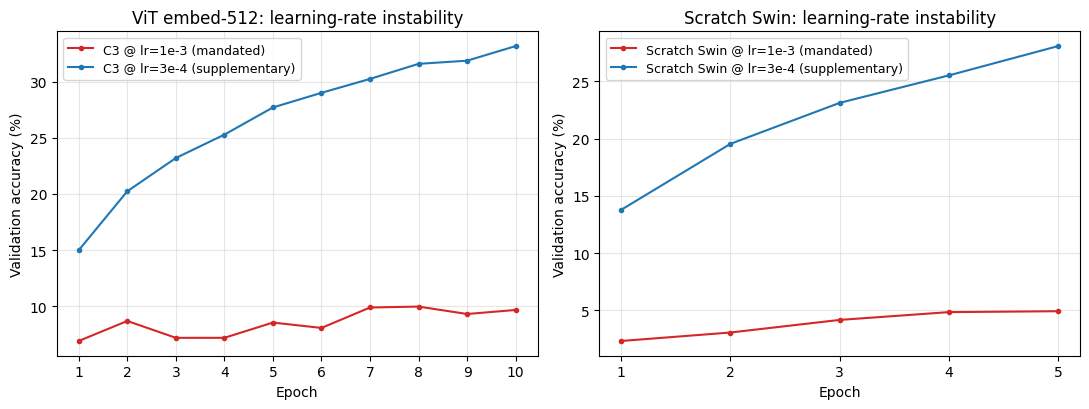

In [19]:
# Figure 2 -- Learning-rate instability of scratch transformers at the
# mandated lr=1e-3: ViT embed-512 (Problem 1) and scratch Swin (Problem 2),
# each compared against the identical architecture at lr=3e-4. Saved to RESULT_DIR.
import matplotlib.pyplot as plt

def _series(hist, col):
    return [h[0] for h in hist], [h[col] for h in hist]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))
ep, acc = _series(results["C3-embed512"]["history"], 2)
ax1.plot(ep, acc, color="tab:red", marker="o", ms=3, label="C3 @ lr=1e-3 (mandated)")
ep, acc = _series(c3_supp_history, 2)
ax1.plot(ep, acc, color="tab:blue", marker="o", ms=3, label="C3 @ lr=3e-4 (supplementary)")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Validation accuracy (%)")
ax1.set_title("ViT embed-512: learning-rate instability")
ax1.legend(fontsize=9); ax1.grid(alpha=0.3); ax1.set_xticks(range(1, 11))

ep, acc = _series(p2_results["Swin-Scratch (32x32)"]["history"], 2)
ax2.plot(ep, acc, color="tab:red", marker="o", ms=3, label="Scratch Swin @ lr=1e-3 (mandated)")
ep, acc = _series(sw_supp_history, 2)
ax2.plot(ep, acc, color="tab:blue", marker="o", ms=3, label="Scratch Swin @ lr=3e-4 (supplementary)")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Validation accuracy (%)")
ax2.set_title("Scratch Swin: learning-rate instability")
ax2.legend(fontsize=9); ax2.grid(alpha=0.3); ax2.set_xticks(range(1, 6))
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, "fig_lr.png"), dpi=160, bbox_inches="tight")
plt.show()

Cell 14 - Problem 2 summary table

In [20]:
# Cell 14 -- Problem 2 summary table
import pandas as pd

p2_rows = []
for name, r in p2_results.items():
    p2_rows.append({
        "Model": name,
        "Total params (M)": r["total_params"] / 1e6,
        "Trainable params": r["trainable_params"],
        "Mean train time/epoch (s)": r["mean_epoch_time"],
        "Best val acc (%)": r["best_val_acc"],
        "Best epoch": r["best_epoch"],
        "Test acc (%)": r["test_acc"],
    })

p2_df = pd.DataFrame(p2_rows)
p2_df = p2_df.round({"Total params (M)": 2,
                     "Mean train time/epoch (s)": 1,
                     "Best val acc (%)": 2, "Test acc (%)": 2})
print(p2_df.to_string(index=False))
print()
print(p2_df.to_markdown(index=False))


                  Model  Total params (M)  Trainable params  Mean train time/epoch (s)  Best val acc (%)  Best epoch  Test acc (%)
 Swin-Tiny (pretrained)             27.60             76900                      220.8             65.46           5         65.51
Swin-Small (pretrained)             48.91             76900                      391.3             69.20           5         69.78
   Swin-Scratch (32x32)             12.18          12176638                       75.9              4.92           5          4.89

| Model                   |   Total params (M) |   Trainable params |   Mean train time/epoch (s) |   Best val acc (%) |   Best epoch |   Test acc (%) |
|:------------------------|-------------------:|-------------------:|----------------------------:|-------------------:|-------------:|---------------:|
| Swin-Tiny (pretrained)  |              27.6  |              76900 |                       220.8 |              65.46 |            5 |          65.51 |
| Swin-Small (pr

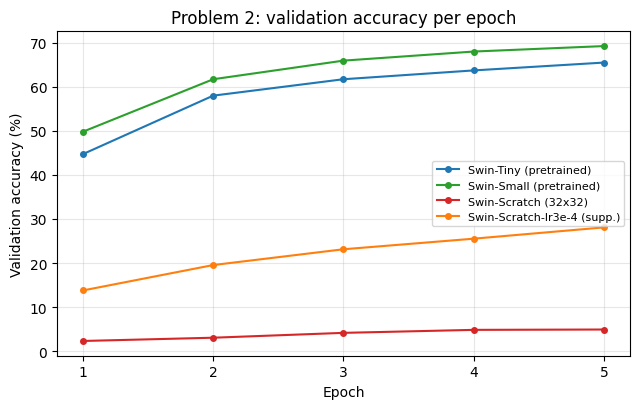

In [21]:
# Figure 3 -- Problem 2 convergence (validation accuracy per epoch),
# including the supplementary scratch run. Saved to RESULT_DIR.
import matplotlib.pyplot as plt

def _series(hist, col):
    return [h[0] for h in hist], [h[col] for h in hist]

fig, ax = plt.subplots(figsize=(6.5, 4.2))
for name, c in [("Swin-Tiny (pretrained)", "tab:blue"),
                ("Swin-Small (pretrained)", "tab:green"),
                ("Swin-Scratch (32x32)", "tab:red")]:
    ep, acc = _series(p2_results[name]["history"], 2)
    ax.plot(ep, acc, marker="o", ms=4, color=c, label=name)
ep, acc = _series(sw_supp_history, 2)
ax.plot(ep, acc, marker="o", ms=4, color="tab:orange", label="Swin-Scratch-lr3e-4 (supp.)")
ax.set_xlabel("Epoch"); ax.set_ylabel("Validation accuracy (%)")
ax.set_title("Problem 2: validation accuracy per epoch")
ax.legend(fontsize=8); ax.grid(alpha=0.3); ax.set_xticks(range(1, 6))
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, "fig_p2.png"), dpi=160, bbox_inches="tight")
plt.show()

In [22]:
# Save Problem 2 results (Drive when available, ./results fallback)
dump_results(p2_results, os.path.join(RESULT_DIR, "p2_results.json"))
print("P2 results saved")


P2 results saved
